In [2]:
import numpy as np
import matplotlib.pyplot as plt
import aopy
import os
import pandas as pds
from db import dbfunctions as db
from ipywidgets import interactive, widgets
import scipy
import h5py
from tqdm.auto import tqdm 
import seaborn as sn
import sklearn
from sklearn.decomposition import PCA
from itertools import compress
# import multiprocessing as mp
import time
import math
# from scipy.fft import fft
import glob
from datetime import date

/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/one/alf/files.py:10: FutureWarning: `one.alf.files` will be removed in version 3.0. Use `one.alf.path` instead.
  warnings.warn(


# Load data and parameters

In [3]:
from local_functions import load_yaml_params

In [4]:
subject = 'beignet'
param_filename = 'spatiotemporal_structure_params.yaml'
ds_params, data_paths, save_paths, filenames, postproc_params, uq_params, analysis_params, vis_params, target_colors = load_yaml_params(param_filename)
align_events = postproc_params['align_events']
    
fig_szs = vis_params['figure_sizes']['paper']
fig_szx_L = fig_szs[1]['large']
fig_szx_S = fig_szs[0]['small']

In [5]:
# load saved decoding accuracy data from both monkeys
lda_results = {}
fr_zscore = {}
lda_metadata = {}

lda_results, fr_zscore, lda_metadata = aopy.data.pkl_read(f"{subject}_{filenames['lda_result']}", save_paths['postproc_data'])
population_results = aopy.data.pkl_read(f"{subject}_{filenames['population_result']}", save_paths['postproc_data'])
nrecs = len(lda_metadata['recording_site'])

# Partition Data

In [6]:
# # Extract rasters of spike data around movement onset
start_idx = lda_metadata['trelevant1_smooth']
end_idx = lda_metadata['trelevant2_smooth']
raster_subset = []
for irec in range(nrecs):
    if fr_zscore[align_events[-1]]['align_spikes_zscore'][irec].shape[1] > 0:
        trial_conc_raster = []
        for itrial in range(fr_zscore[align_events[-1]]['align_spikes_zscore'][irec].shape[2]):
            trial_conc_raster.append(fr_zscore[align_events[-1]]['align_spikes_zscore_smooth'][irec][start_idx:end_idx,:,itrial])

        raster_subset.append(np.concatenate(trial_conc_raster))
        
    else:
        raster_subset.append([])
    

# Apply functional connectivity analysis

In [7]:
site_decoding_accuracy = np.array([np.mean(lda_results[align_events[-1]]['penetration_score'][irec]) for irec in range(nrecs)])
site_decoding_accuracy_order = np.argsort(site_decoding_accuracy)
print(np.round(site_decoding_accuracy[site_decoding_accuracy_order], 3))
print(lda_metadata['recording_site'][site_decoding_accuracy_order])

[0.402 0.48  0.492 0.497 0.508 0.574 0.612 0.642 0.701 0.734 0.771 0.785
 0.858   nan   nan   nan]
[  9  10  30  22  56  18  11  40  47  98 120 121  45  11   9   9]


/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | 0/16 [00:00<?, ?it/s]

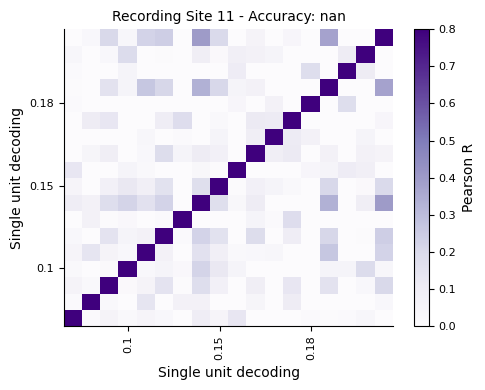

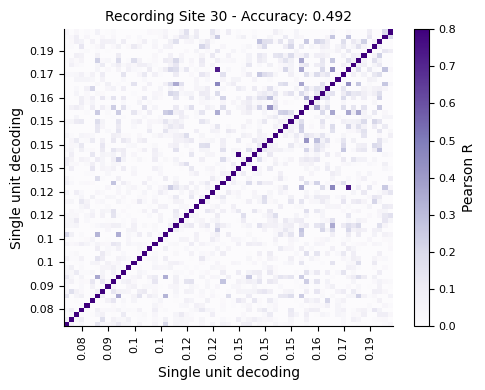

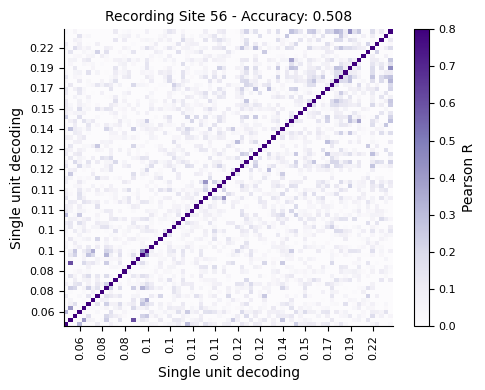

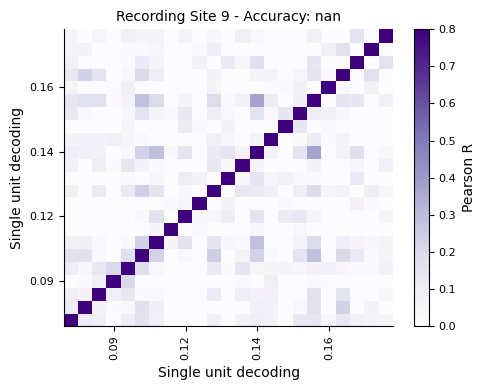

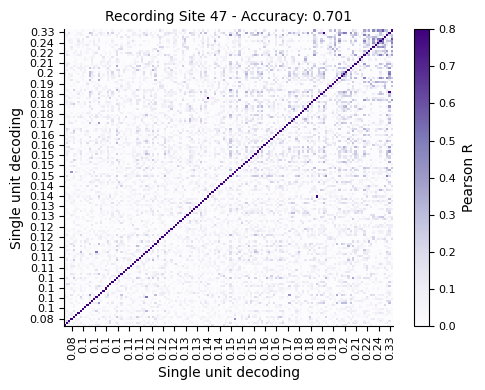

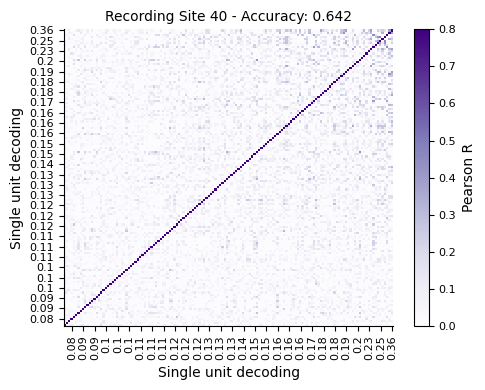

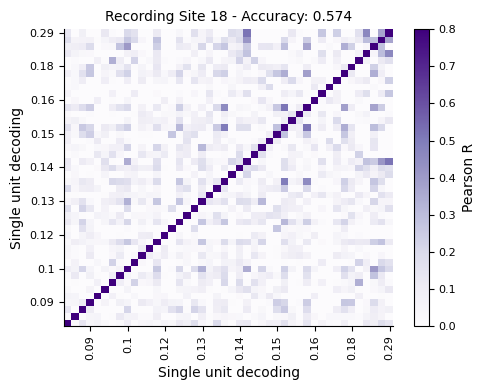

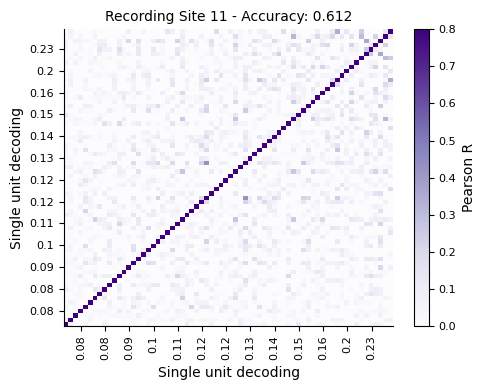

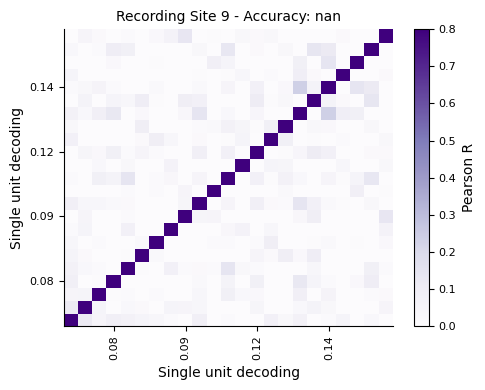

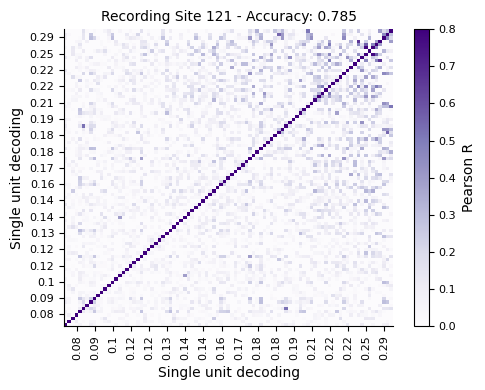

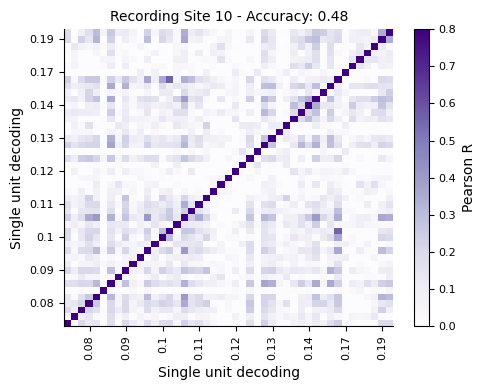

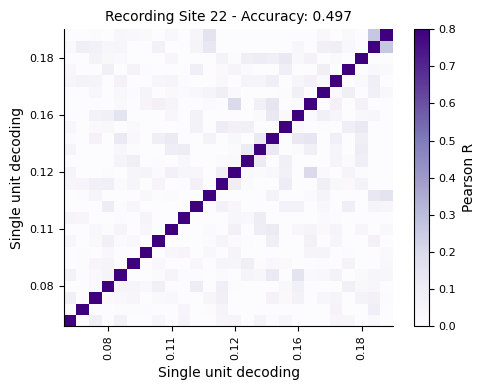

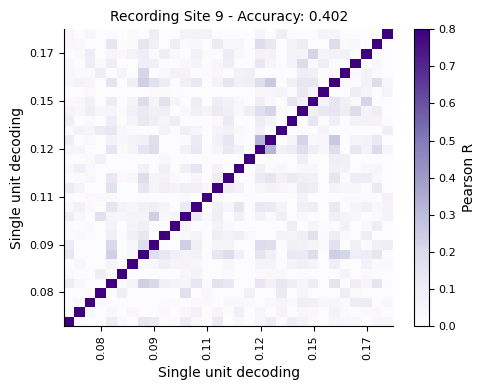

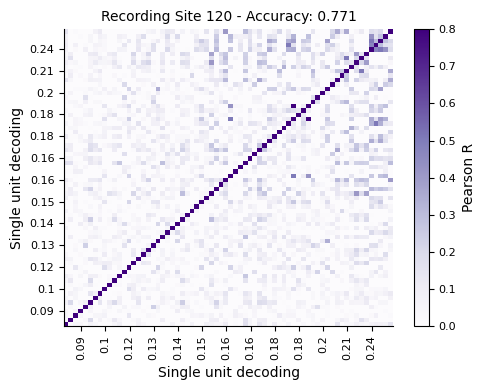

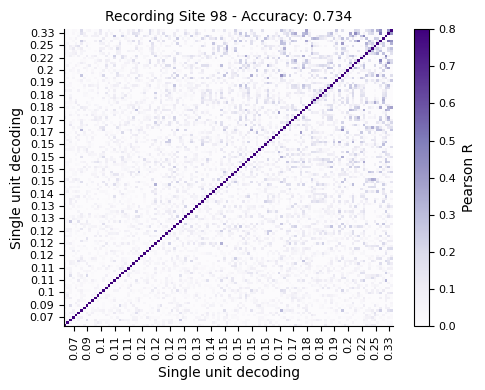

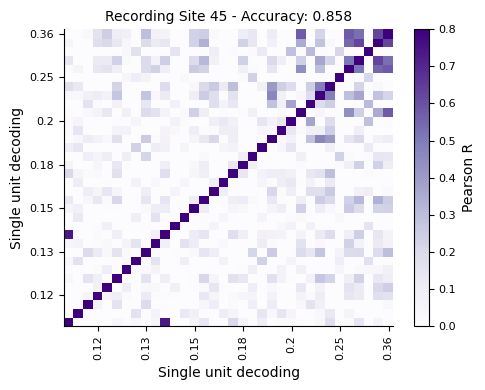

In [8]:
func_connectivity = {}
func_connectivity['pcc'] = {}
func_connectivity['pcc']['all'] = []

# Pearson correlation
for irec in tqdm(range(nrecs)):
    if len(raster_subset[irec]) > 0:
        nunits = raster_subset[irec].shape[1]
        unit_pcc = np.zeros((nunits, nunits))*np.nan
        for iunit1 in range(nunits):
            for iunit2 in range(nunits):
                unit_pcc[iunit1,iunit2] = scipy.stats.pearsonr(raster_subset[irec][:,iunit1], raster_subset[irec][:,iunit2])[0]
        func_connectivity['pcc']['all'].append(unit_pcc)
        unit_decoding = np.mean(lda_results[align_events[-1]]['single_ch_decoding'][irec], axis=1)
        unit_order = np.argsort(unit_decoding)
        fig, ax = plt.subplots(1,1,figsize=(5,4))
        im1 = ax.pcolor(np.arange(nunits), np.arange(nunits), unit_pcc[unit_order,:][:,unit_order], cmap='Purples')
        plt.colorbar(im1, label='Pearson R')
        im1.set_clim(0,0.8)
        ax.set_xticks(np.arange(nunits)[3::5], np.round(unit_decoding[unit_order][3::5], 2), rotation=90)
        ax.set_yticks(np.arange(nunits)[3::5], np.round(unit_decoding[unit_order][3::5], 2))
        ax.set(xlabel='Single unit decoding', ylabel='Single unit decoding', title=f"Recording Site {lda_metadata['recording_site'][irec]} - Accuracy: {np.round(site_decoding_accuracy[irec], 3)}")
        fig.tight_layout()
        plt.show()

In [53]:
func_connectivity['pcc']['high_high_dec'] = []
func_connectivity['pcc']['high_any_dec'] = []
func_connectivity['pcc']['any_any_dec'] = []
for irec in tqdm(range(nrecs)):
    if len(raster_subset[irec]) > 0:
        unit_decoding = np.mean(lda_results[align_events[-1]]['single_ch_decoding'][irec], axis=1)
        # unit_order = np.argsort(unit_decoding)
        high_dec_unit = unit_decoding >= population_results[align_events[-1]]['low_v_high']['high_dec_thresh']
        other_dec_unit = unit_decoding <= population_results[align_events[-1]]['low_v_high']['high_dec_thresh']
        
        test = func_connectivity['pcc']['all'][irec][high_dec_unit,:][:,high_dec_unit] 
        test[np.triu_indices(np.sum(high_dec_unit))] = np.nan
        func_connectivity['pcc']['high_high_dec'].extend(test[~np.isnan(test)])
        
        test2 = func_connectivity['pcc']['all'][irec][other_dec_unit,:][:,other_dec_unit] 
        test2[np.triu_indices(np.sum(other_dec_unit))] = np.nan
        func_connectivity['pcc']['high_any_dec'].extend(test2[~np.isnan(test2)])
        
        test3 = func_connectivity['pcc']['all'][irec][high_dec_unit,:][:,other_dec_unit]
        test2[np.triu_indices(np.sum(other_dec_unit))] = np.nan
        func_connectivity['pcc']['any_any_dec'].extend(func_connectivity['pcc']['all'][irec][high_dec_unit,:][:,other_dec_unit].flatten())

  0%|          | 0/16 [00:00<?, ?it/s]

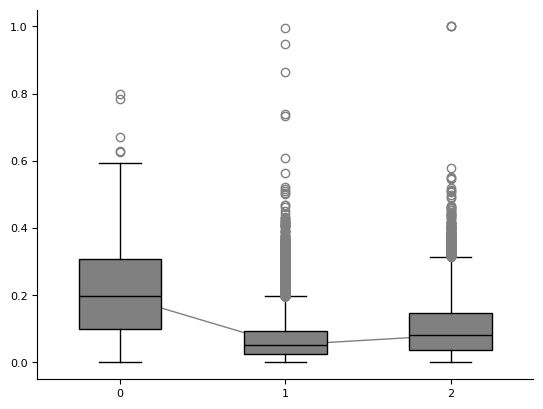

In [55]:
boxplot_list = [np.abs(np.array(func_connectivity['pcc']['high_high_dec'])), np.abs(np.array(func_connectivity['pcc']['high_any_dec'])), np.abs(np.array(func_connectivity['pcc']['any_any_dec']))]
aopy.visualization.plot_boxplots(boxplot_list, [0,1,2])